<center><h1> <b> Object Detection Using YOLO <b> </h1></center>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This tutorial is designed to provide a comprehensive understanding of how to use YOLO, a state-of-the-art method in computer vision, for detecting objects in images.

Object detection and classification is a key technology in many areas, such as automated vehicles, security, and even healthcare.

We will begin with the basics of preparing (pre processing) an image dataset, ensuring it is ready for effective model training.We will then explore how YOLO, a type of convolutional neural network, automatically extracts features from images to recognize different objects. Understanding this process is crucial for grasping how YOLO operates.

The core of this tutorial is focused on transfer learning using YOLO. We will teach you how to take a pre-trained YOLO model and adapt it to a new dataset. This technique is efficient and powerful, allowing us to harness the strengths of YOLO with less computational effort.

By the end of this tutorial, you will have hands-on experience with preparing data, implementing YOLO, and understanding the principles behind it. This tutorial aims to equip students with practical skills and knowledge in one of the most exciting fields in technology.

Since its inception, the YOLO family of object detection models has come a long way. YOLOv8 is the most recent addition to this famous anchor-based single-shot family of object detectors. It comes with a bunch of improvements which include state-of-the-art accuracy and speed.  In this article, we will be fine tuning the YOLOv8 object detection model on a real-world pothole detection dataset.

In the previous lecture, you were asked to make your own custom datasets for a project you want to work on. Today we will explore how to finetune YOLO on a certain dataset.  

Importing required Libraries

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2
import seaborn as sns
import glob
import xml.etree.ElementTree as ET
from PIL import Image
import os
import shutil

# Dataset Description






Fruit Images for Object Detection

available on kaggle => https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection


- 240 images in train folder. 60 images in test folder.

- 3 different fruits:

    - Apple

    - Banana

    - Orange

The labels are in xml format, which is Extensible markup language.Storing image dataset labels in XML format is quite common. XML provides a clear, hierarchical structure which is ideal for representing the complex data associated with image labels. This includes not just the class of the object, but potentially a wealth of other information like bounding box coordinates, object IDs, and additional metadata.


# Data Preprocessing

For preprocessing:
- We have to convert the dataset into that acceptable by YOLO.
  - Heirarchy of folders should be the one accepted by YOLO
  - Labels format should be darknet YOLO.
  - Labels files should be .txt files
- Check and see if there are any missing labels or images. And remove them from dataset.


## Heirarchy of Folders correction

Defining paths to train and test folders.

In [ ]:
# test_dir = '/content/drive/MyDrive/fruits/test_zip/test'
# train_dir = '/content/drive/MyDrive/fruits/train_zip/train'

In [ ]:
#train_dir = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Train/apple/apple images'
train_dir_apple = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Train/apple/apple images'
train_dir_banana = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Train/banana/banana images'
train_dir_orange = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Train/orange/orange images'
train_dir_broccoli = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Train/broccoli/broccoli images'

train_dir_apple_labels = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Train/apple/apple labels'
train_dir_banana_labels = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Train/banana/banana labels'
train_dir_orange_labels = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Train/orange/orange labels'
train_dir_broccoli_labels = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Train/broccoli/broccoli labels'

test_dir = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images'

test_dir_labels = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/labels'
# #For the testing data that was arranged differently than the rest
# test_dir_orange_ripe = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Orange/Ripe'
# test_dir_orange_unederripe = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Orange/Underripe'

# test_dir_broccoli_ripe = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Broccoli/Ripe'
# test_dir_broccoli_rotten = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Broccoli/rotten' #intentional lowercasse
# test_dir_broccoli_underripe = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Broccoli/Underripe'

# # Banana has an image with multiple ripeness types
# test_dir_banana = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Banana'
# test_dir_banana_ripe = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Banana/Ripe'
# test_dir_banana_rotten = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Banana/Rotten'
# test_dir_banana_underripe = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Banana/Underripe'


# test_dir_apple_ripe = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Apple/Ripe'
# test_dir_apple_rotten = '/content/drive/MyDrive/IAT 360 CV Project/Dataset/Test/images/Laraine\'s/Apple/Rotten'



The train and test folders have all the images and labels together.

But for YOLO, the directories should be in:

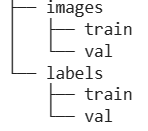


Making directories according to above struture of folders

In [ ]:
#import os
#run it once for making directories

#os.makedirs('/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data')
os.makedirs('/content/drive/MyDrive/IAT 360 CV Project/Final_data')
os.makedirs('/content/drive/MyDrive/IAT 360 CV Project/Final_data/images')
os.makedirs('/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels')
os.makedirs('/content/drive/MyDrive/IAT 360 CV Project/Final_data/images/train')
os.makedirs('/content/drive/MyDrive/IAT 360 CV Project/Final_data/images/val')
os.makedirs('/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/train')
os.makedirs('/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val')

# os.makedirs('/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/images')
# os.makedirs('/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/labels')
# os.makedirs('/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/images/train')
# os.makedirs('/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/images/val')
# os.makedirs('/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/labels/train')
# os.makedirs('/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/labels/val')

In [ ]:
label_dir= "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels"
image_dir="/content/drive/MyDrive/IAT 360 CV Project/Final_data/images"

#set the paths to labels and images directory
# label_dir= "/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/labels"
# image_dir="/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/images"


Copy XML files and jpg files from the train folder to the folders created.

In [ ]:
#import shutil
#run it once for copying!
#train_dirs = [train_dir_apple, train_dir_banana, train_dir_orange, train_dir_broccoli]

# for file in os.listdir(train_dir):
#     if file.endswith(".xml"):
#         shutil.copy(os.path.join(train_dir, file), os.path.join(label_dir, "train"))
#     if file.endswith(".jpg"):
#         image = Image.open(os.path.join(train_dir, file))
#         image = image.convert("RGB")
#         new_filename = os.path.splitext(file)[0] + ".jpg"
#         image.save(os.path.join(image_dir,"train", new_filename), "JPEG")
#         #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))
#     if file.endswith(".png"):
#         image = Image.open(os.path.join(train_dir, file))
#         image = image.convert("RGB")
#         new_filename = os.path.splitext(file)[0] + ".png"
#         image.save(os.path.join(image_dir,"train", new_filename), "PNG")
#         #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))

# Apples training
for file in os.listdir(train_dir_apple):
    if file.endswith(".xml"):
        shutil.copy(os.path.join(train_dir_apple, file), os.path.join(label_dir, "train"))
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir_apple, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train", new_filename), "JPEG")
        #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))
    if file.endswith(".png"):
        image = Image.open(os.path.join(train_dir_apple, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".png"
        image.save(os.path.join(image_dir,"train", new_filename), "PNG")
        #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))

# Bananas training
for file in os.listdir(train_dir_banana):
    if file.endswith(".xml"):
        shutil.copy(os.path.join(train_dir_banana, file), os.path.join(label_dir, "train"))
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir_banana, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train", new_filename), "JPEG")
        #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))
    if file.endswith(".png"):
        image = Image.open(os.path.join(train_dir_banana, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".png"
        image.save(os.path.join(image_dir,"train", new_filename), "PNG")
        #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))

#Oranges training
for file in os.listdir(train_dir_orange):
    if file.endswith(".xml"):
        shutil.copy(os.path.join(train_dir_orange, file), os.path.join(label_dir, "train"))
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir_orange, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train", new_filename), "JPEG")
        #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))
    if file.endswith(".png"):
        image = Image.open(os.path.join(train_dir_orange, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".png"
        image.save(os.path.join(image_dir,"train", new_filename), "PNG")
        #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))

# Broccoli training
for file in os.listdir(train_dir_broccoli):
    if file.endswith(".xml"):
        shutil.copy(os.path.join(train_dir_broccoli, file), os.path.join(label_dir, "train"))
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(train_dir_broccoli, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"train", new_filename), "JPEG")
        #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))
    if file.endswith(".png"):
        image = Image.open(os.path.join(train_dir_broccoli, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".png"
        image.save(os.path.join(image_dir,"train", new_filename), "PNG")
        #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))

# Testing data. It wasn't separated by vegetables but rather already put into one folder
# Hence, one for loop.
# #Copy XML files and jpg files from the test folder to the folders created.
for file in os.listdir(test_dir):
    if file.endswith(".xml"):
        shutil.copy(os.path.join(test_dir, file), os.path.join(label_dir, "val"))
    if file.endswith(".jpg"):
        image = Image.open(os.path.join(test_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".jpg"
        image.save(os.path.join(image_dir,"val", new_filename), "JPEG")
        #shutil.copy(os.path.join(test_dir, file), os.path.join(image_dir, "val"))
    if file.endswith(".png"):
        image = Image.open(os.path.join(test_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".png"
        image.save(os.path.join(image_dir,"val", new_filename), "PNG")
        #shutil.copy(os.path.join(test_dir, file), os.path.join(image_dir, "val"))
    if file.endswith(".webp"):
        image = Image.open(os.path.join(test_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".webp"
        image.save(os.path.join(image_dir,"val", new_filename), "WEBP")
        #shutil.copy(os.path.join(test_dir, file), os.path.join(image_dir, "val"))
    if file.endswith("avif"):
        image = Image.open(os.path.join(test_dir, file))
        image = image.convert("RGB")
        new_filename = os.path.splitext(file)[0] + ".avif"
        image.save(os.path.join(image_dir,"val", new_filename), "AVIF")
        #shutil.copy(os.path.join(test_dir, file), os.path.join(image_dir, "val"))

In [ ]:
# Moving labels from testing dataset into validation.
for file in os.listdir(test_dir_labels):
    if file.endswith(".txt"):
        shutil.copy(os.path.join(test_dir_labels, file), os.path.join(label_dir, "val"))

In [ ]:
for file in os.listdir(train_dir_apple_labels):
    if file.endswith(".txt"):
        shutil.copy(os.path.join(train_dir_apple_labels, file), os.path.join(label_dir, "train"))

for file in os.listdir(train_dir_banana_labels):
    if file.endswith(".txt"):
        shutil.copy(os.path.join(train_dir_banana_labels, file), os.path.join(label_dir, "train"))

for file in os.listdir(train_dir_orange_labels):
    if file.endswith(".txt"):
        shutil.copy(os.path.join(train_dir_orange_labels, file), os.path.join(label_dir, "train"))

for file in os.listdir(train_dir_broccoli_labels):
    if file.endswith(".txt"):
        shutil.copy(os.path.join(train_dir_broccoli_labels, file), os.path.join(label_dir, "train"))
    # if file.endswith(".jpg"):
    #     image = Image.open(os.path.join(train_dir_apple, file))
    #     image = image.convert("RGB")
    #     new_filename = os.path.splitext(file)[0] + ".jpg"
    #     image.save(os.path.join(image_dir,"train", new_filename), "JPEG")
    #     #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))
    # if file.endswith(".png"):
    #     image = Image.open(os.path.join(train_dir_apple, file))
    #     image = image.convert("RGB")
    #     new_filename = os.path.splitext(file)[0] + ".png"
    #     image.save(os.path.join(image_dir,"train", new_filename), "PNG")
    #     #shutil.copy(os.path.join(train_dir, file), os.path.join(image_dir, "train"))

Visualizing somme pictures from the dataset

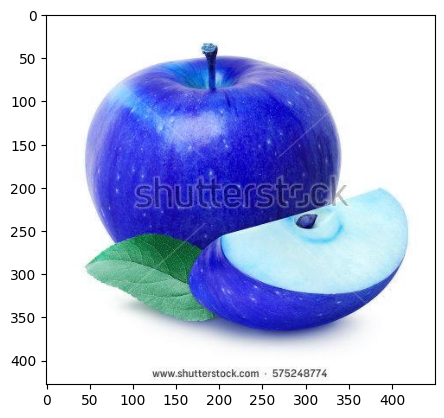

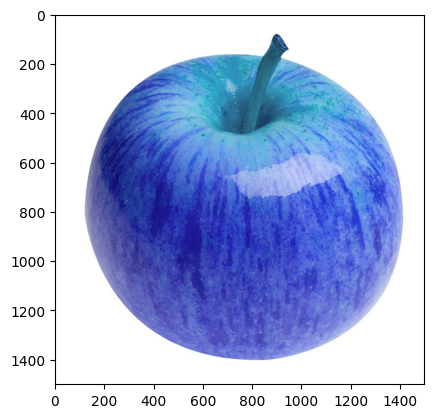

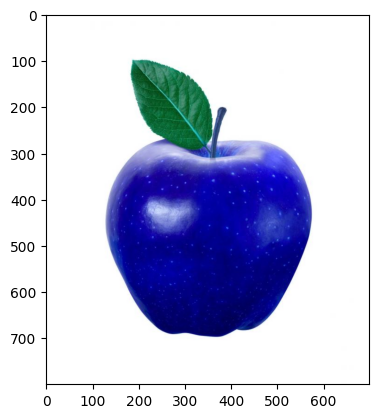

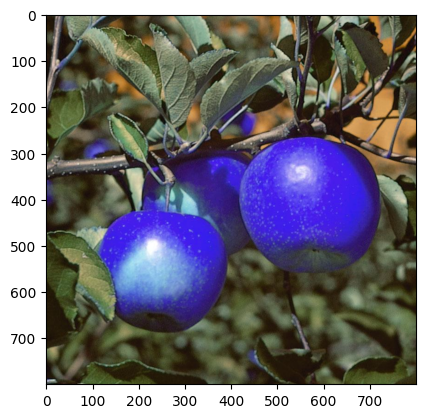

In [ ]:
#visualize first four sample images from train data
for idx, image in enumerate(os.listdir(os.path.join(image_dir, "train"))):
    img = cv2.imread(os.path.join(image_dir,"train", image), 1)
    plt.imshow(img)
    plt.show()

    if idx == 3:
        break

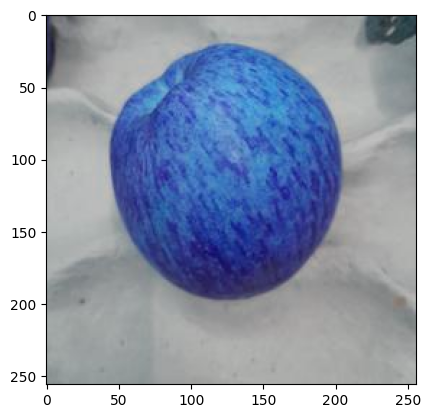

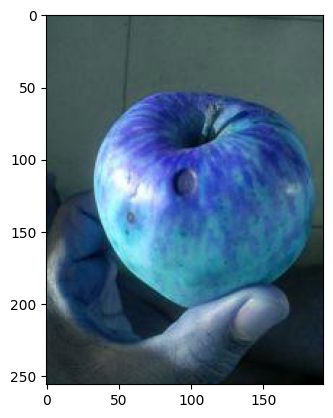

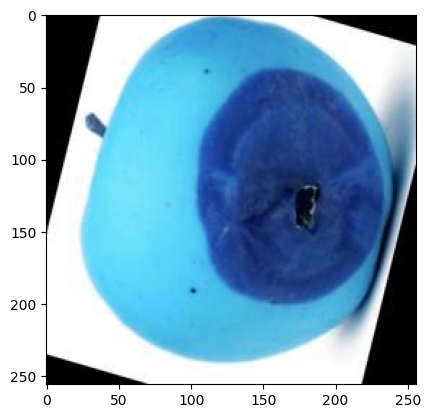

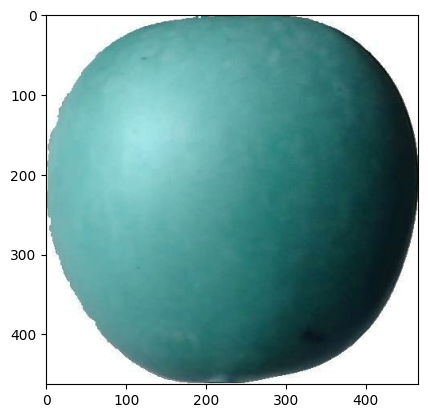

In [ ]:
#visualize first four sample images from train data
for idx, image in enumerate(os.listdir(os.path.join(image_dir, "train"))):
    img = cv2.imread(os.path.join(image_dir,"train", image), 1)
    plt.imshow(img)
    plt.show()

    if idx == 3:
        break

## Creating Text files for labels
Creating Dataframes from .xml files, from which we will eventually create .txt file for each image


In [ ]:
#import glob
#import xml.etree.ElementTree as ET

df = {'name': [],
      'label': [],
      'width': [],
      'height': [],
     'xmin': [],
     'ymin': [],
     'xmax': [],
     'ymax': []}


#This is the way to handle xml format files which are in heirarchial form (trees).

for idx, anno in enumerate(glob.glob(label_dir+"/train" + '/*.xml')):

    trees = ET.parse(anno)

    print(anno)
    root = trees.getroot()
    width, height = [], []
    for item in root.iter():
        print(item)

        if item.tag == 'size':
            for attr in list(item):
                if attr.tag == 'width':
                    width =int(round(float(attr.text)))
                if attr.tag == 'height':
                    height = int(round(float(attr.text)))

        if item.tag == 'object':
            for attr in list(item):
                if 'name' in attr.tag:
                    label = attr.text
                    df['label'] += [label]
                    df['width'] += [width]
                    df['height'] += [height]
                    df['name'] += [anno.split('/')[-1][0:-4]]

                if 'bndbox' in attr.tag:
                    for dim in attr:
                        if dim.tag == 'xmin':
                            xmin = int(round(float(dim.text)))
                            df['xmin'] += [xmin]

                        if dim.tag == 'ymin':
                            ymin = int(round(float(dim.text)))
                            df['ymin'] += [ymin]
                        if dim.tag == 'xmax':
                            xmax = int(round(float(dim.text)))
                            df['xmax'] += [xmax]
                        if dim.tag == 'ymax':
                            ymax = int(round(float(dim.text)))
                            df['ymax'] += [ymax]

Streaming output truncated to the last 5000 lines.
<Element 'depth' at 0x781b3ecdf920>
<Element 'segmented' at 0x781b3ecdff10>
<Element 'object' at 0x781b3ecdf9c0>
<Element 'name' at 0x781b3ecdffb0>
<Element 'pose' at 0x781b3ecdfa10>
<Element 'truncated' at 0x781b3ecdf970>
<Element 'difficult' at 0x781b3ecdf830>
<Element 'bndbox' at 0x781b3ecdfb50>
<Element 'xmin' at 0x781b3ecdff60>
<Element 'ymin' at 0x781b3ecdfb00>
<Element 'xmax' at 0x781b3ecdf880>
<Element 'ymax' at 0x781b3ebc1170>
<Element 'object' at 0x781b3ebc1210>
<Element 'name' at 0x781b3ebc1030>
<Element 'pose' at 0x781b3ebc0fe0>
<Element 'truncated' at 0x781b3ebc15d0>
<Element 'difficult' at 0x781b3ebc1760>
<Element 'bndbox' at 0x781b3ebc1300>
<Element 'xmin' at 0x781b3ebc1080>
<Element 'ymin' at 0x781b3ebc0590>
<Element 'xmax' at 0x781b3ebc10d0>
<Element 'ymax' at 0x781b3ebc0a90>
/content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/labels/train/apple_70.xml
<Element 'annotation' at 0x781b3ecded40>
<Element 'fold

Doing the same for validation data labels.


In [ ]:
#import glob
#import xml.etree.ElementTree as ET

df2 = {'name': [],
      'label': [],
      'width': [],
      'height': [],
     'xmin': [],
     'ymin': [],
     'xmax': [],
     'ymax': []}


#This is the way to handle xml format files which are in heirarchial form (tees).

for idx, anno in enumerate(glob.glob(label_dir+"/val" + '/*.xml')):

    trees = ET.parse(anno)

    #print(anno)
    root = trees.getroot()
    width, height = [], []
    for item in root.iter():
        #print(item)

        if item.tag == 'size':
            for attr in list(item):
                if attr.tag == 'width':
                    width =int(round(float(attr.text)))
                if attr.tag == 'height':
                    height = int(round(float(attr.text)))

        if item.tag == 'object':
            for attr in list(item):
                if 'name' in attr.tag:
                    label = attr.text
                    df2['label'] += [label]
                    df2['width'] += [width]
                    df2['height'] += [height]
                    #dataset['name']+=[anno.split('/')[-1][0:-4]]
                    df2['name'] += [anno.split('/')[-1][0:-4]]

                if 'bndbox' in attr.tag:
                    for dim in attr:
                        if dim.tag == 'xmin':
                            xmin = int(round(float(dim.text)))
                            df2['xmin'] += [xmin]

                        if dim.tag == 'ymin':
                            ymin = int(round(float(dim.text)))
                            df2['ymin'] += [ymin]
                        if dim.tag == 'xmax':
                            xmax = int(round(float(dim.text)))
                            df2['xmax'] += [xmax]
                        if dim.tag == 'ymax':
                            ymax = int(round(float(dim.text)))
                            df2['ymax'] += [ymax]

In [ ]:
import pandas as pd
train_df = pd.DataFrame(df)
val_df=pd.DataFrame(df2)
#df1.head()
val_df.head()

,name,label,width,height,xmin,ymin,xmax,ymax
0,banana_85,banana,2679,1506,419,297,2602,1034
1,banana_77,banana,300,360,29,11,246,348
2,banana_81,banana,766,547,25,135,663,543
3,banana_81,banana,766,547,86,92,736,385
4,banana_83,banana,630,355,63,17,560,323


In [ ]:
train_df.head(5)

,name,label,width,height,xmin,ymin,xmax,ymax
0,apple_12,apple,450,428,43,21,350,353
1,apple_15,apple,1400,1046,643,364,1396,1046
2,apple_1,apple,0,0,8,15,331,349
3,apple_13,apple,800,800,415,261,720,567
4,apple_13,apple,800,800,105,426,393,691


Visualizing one of the image in train set with the bounding box

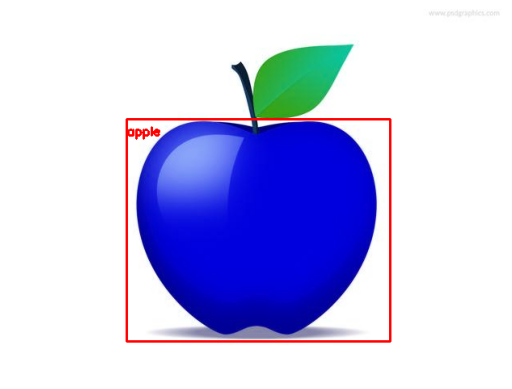

In [ ]:
index= 10 #picture to visualize

#import cv2
image = cv2.imread(os.path.join(image_dir,"train", train_df["name"][index]+".jpg"), 1)
# Draw rectangle
cv2.rectangle(image, (train_df['xmin'][index], train_df['ymin'][index]), (train_df['xmax'][index], train_df['ymax'][index]), (255, 0, 0), 2)
# Put label (class_id) near the bbox
label = train_df["label"][index]
cv2.putText(image, str(label), (train_df['xmin'][index], train_df['ymin'][index]+20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)
# Display image
plt.imshow(image)
plt.axis('off')
plt.show()

Checking to see if the above image has bounding boxes around other apples or not.

In [ ]:
train_df["name"][index]
filtered_df = train_df[train_df['name'] == train_df["name"][index]]
print(filtered_df)

        name  label  width  height  xmin  ymin  xmax  ymax
10  apple_18  apple    610     458   144   136   470   411


Checking to see the datatypes of all the columns and if there is any null value that needs to be eliminated from the data.

In [ ]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   name    117 non-null    object
 1   label   117 non-null    object
 2   width   117 non-null    int64 
 3   height  117 non-null    int64 
 4   xmin    117 non-null    int64 
 5   ymin    117 non-null    int64 
 6   xmax    117 non-null    int64 
 7   ymax    117 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 7.4+ KB


What different types of labels are assigned to each sample and checking if they match the provided label/class information, i.e. there are no extra labels due to mistakes in spellings etc.

In [ ]:
print(train_df['label'].unique())
print(val_df['label'].unique())

['apple' 'banana' 'orange']
['banana' 'apple' 'orange']


We need to map labels to class_ids required for YOLO

In [ ]:
label_map = { 'orange': 0,
            'apple': 1,
            'banana': 2}

train_df['class'] = train_df['label'].map(label_map)
val_df['class'] = val_df['label'].map(label_map)

In [ ]:
train_df.head()

,name,label,width,height,xmin,ymin,xmax,ymax,class
0,apple_12,apple,450,428,43,21,350,353,1
1,apple_15,apple,1400,1046,643,364,1396,1046,1
2,apple_1,apple,0,0,8,15,331,349,1
3,apple_13,apple,800,800,415,261,720,567,1
4,apple_13,apple,800,800,105,426,393,691,1


convertig the bounding box format to the one required by YOLO:




In [ ]:
# Training data
train_df['x_center'] = (train_df['xmin']+train_df['xmax'])/(2*train_df["width"])
train_df['y_center'] = (train_df['ymin']+train_df['ymax'])/(2*train_df["height"])
train_df['box_width'] = (train_df['xmax']-train_df['xmin'])/ train_df["width"]
train_df['box_height'] = (train_df['ymax']-train_df['ymin'])/train_df["height"]

#Validation data
val_df['x_center'] = (val_df['xmin']+val_df['xmax'])/(2*val_df["width"])
val_df['y_center'] = (val_df['ymin']+val_df['ymax'])/(2*val_df["height"])
val_df['box_width'] = (val_df['xmax']-val_df['xmin'])/ val_df["width"]
val_df['box_height'] = (val_df['ymax']-val_df['ymin'])/val_df["height"]

In [ ]:
train_df.head()

,name,label,width,height,xmin,ymin,xmax,ymax,class,x_center,y_center,box_width,box_height
0,apple_12,apple,450,428,43,21,350,353,1,0.436667,0.436916,0.682222,0.775701
1,apple_15,apple,1400,1046,643,364,1396,1046,1,0.728214,0.673996,0.537857,0.652008
2,apple_1,apple,0,0,8,15,331,349,1,inf,inf,inf,inf
3,apple_13,apple,800,800,415,261,720,567,1,0.709375,0.517500,0.381250,0.382500
4,apple_13,apple,800,800,105,426,393,691,1,0.311250,0.698125,0.360000,0.331250


Deleting all the sample with Nan values in training and validation data

In [ ]:
#training
print("before deleting (train data): " , train_df.shape)
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
train_df.dropna(inplace=True)
print("after deleting(train_data): " ,train_df.shape)

#validation
print("before deleting (val data): " , val_df.shape)
val_df.replace([np.inf, -np.inf], np.nan, inplace=True)
val_df.dropna(inplace=True)
print("after deleting(val data): " , val_df.shape)



before deleting (train data):  (465, 13)
after deleting(train_data):  (420, 13)
before deleting (val data):  (117, 13)
after deleting(val data):  (110, 13)


converting the dataframe to type *str* (string) to be stored in text files.

In [ ]:
train_df = train_df.astype(str)
val_df = val_df.astype(str)

If there are more than one bounding boxes in single image, they should be written in one text file. As, you can see in the below example that one image has so many bounding boxes.

In [ ]:
filtered_df = train_df[train_df['name'] == train_df["name"][3]]
(filtered_df.head(15))

,name,label,width,height,xmin,ymin,xmax,ymax,class,x_center,y_center,box_width,box_height
3,apple_13,apple,800,800,415,261,720,567,1,0.709375,0.5175,0.38125,0.3825
4,apple_13,apple,800,800,105,426,393,691,1,0.31125,0.698125,0.36,0.33125
5,apple_13,apple,800,800,194,290,477,545,1,0.419375,0.521875,0.35375,0.31875


In [ ]:
#file_name = [x.split('.')[0] for x in df1["name"]]

#TRAINING DATA
#finding all the unique names:
unique_names= train_df['name'].unique()

#for each unique name, containing multiple bboxes, combine them together.
for name in unique_names:
  data = train_df[train_df.name == name]
  box_list = []
  for idx in range(len(data)):
        row = data.iloc[idx]
        box_list.append(row['class']+" "+row['x_center']+" "+row['y_center']+" "+ row['box_width']+" "+row['box_height'])

#writing on text files
  text = "\n".join(box_list)
  with open(f'{label_dir}/train/{name}.txt', 'w') as file:
            file.write(text)
#############################################################################################
#VALIDATION DATA
#finding all the unique names:
unique_names= val_df['name'].unique()

#for each unique name, containing multiple bboxes, combine them together.
for name in unique_names:
  data = val_df[val_df.name == name]
  box_list = []
  for idx in range(len(data)):
        row = data.iloc[idx]
        box_list.append(row['class']+" "+row['x_center']+" "+row['y_center']+" "+ row['box_width']+" "+row['box_height'])

#writing on text files
  text = "\n".join(box_list)
  with open(f'{label_dir}/val/{name}.txt', 'w') as file:
            file.write(text)

## Checking Missing Files

Checking the folders if every image file has a corresponding label file


(We will copy the code, we already used in previous turorial after updating)

In [ ]:
#The lists of all the images and labels for train and validation set:
train_images=glob.glob(os.path.join(image_dir, "train",'*.jpg'))
train_labels=glob.glob(os.path.join(label_dir, "train",'*.txt'))
val_images=glob.glob(os.path.join(image_dir, "val",'*.jpg'))
val_labels=glob.glob(os.path.join(label_dir, "val",'*.txt'))
#print(val_labels)

# Get the list of filenames without extensions
image_files_train = {file.split("/")[-1].split(".")[0] for file in train_images}
label_files_train = {file.split("/")[-1].split(".")[0] for file in train_labels}

image_files_val = {file.split("/")[-1].split(".")[0] for file in val_images}
label_files_val = {file.split("/")[-1].split(".")[0] for file in val_labels}
#print(image_files_val)



In [ ]:
# OUR VERSION:

#The lists of all the images and labels for train and validation set:
train_images=glob.glob(os.path.join(image_dir, "train",'*.jpg'))
train_labels=glob.glob(os.path.join(label_dir, "train",'*.txt'))
val_images=glob.glob(os.path.join(image_dir, "val",'*.jpg'))
val_labels=glob.glob(os.path.join(label_dir, "val",'*.txt'))

val_images_png=glob.glob(os.path.join(image_dir, "val",'*.png'))
val_images_webm=glob.glob(os.path.join(image_dir, "val",'*.webm'))
val_images_avif=glob.glob(os.path.join(image_dir, "val", '*.avif'))
#print(val_labels)

# Get the list of filenames without extensions
image_files_train = {file.split("/")[-1].split(".")[0] for file in train_images}
label_files_train = {file.split("/")[-1].split(".")[0] for file in train_labels}

image_files_val = {file.split("/")[-1].split(".")[0] for file in val_images}
image_files_val_png = {file.split("/")[-1].split(".")[0] for file in val_images_png}
image_files_val_webm = {file.split("/")[-1].split(".")[0] for file in val_images_webm}
image_files_val_avif = {file.split("/")[-1].split(".")[0] for file in val_images_avif}

label_files_val = {file.split("/")[-1].split(".")[0] for file in val_labels}
#print(image_files_val_png)



{'43eb3a63-broccoli_rotten_1', '684c62a5-banana_rotten_1', 'bcf9c43b-apple_unripe_1', 'b8e4ba80-apple_overripe_1', '506111_16'}


In [ ]:
print(len(image_files_val), "  =  ", len(label_files_val))

56   =   56


In [ ]:
# OUR VERSION
# print(len(image_files_val) + len(image_files_val_png) + len(image_files_val_avif) + len(image_files_val_webm), "  =  ", len(label_files_val))

print(len(image_files_val) + len(image_files_val_png), "  =  ", len(label_files_val))

104   =   120


In [ ]:
print(len(image_files_train), "  =  ", len(label_files_train))

207   =   207


In [ ]:
#OUR VERSION
print(len(image_files_train), "  =  ", len(label_files_train))

523   =   523


In [ ]:
# Find extra files in each folder

#TRAINING DATA
extra_images_train = image_files_train - label_files_train
extra_labels_train = label_files_train - image_files_train

# Output the results
print(f"Training Extra images (without corresponding labels): {extra_images_train}")
print(f"Training Extra labels (without corresponding images): {extra_labels_train}")


#VALIDATION DATA
extra_images_val = image_files_val - label_files_val
extra_labels_val = label_files_val - image_files_val

# Output the results
print(f"Validation Extra images (without corresponding labels): {extra_images_val}")
print(f"Validation Extra labels (without corresponding images): {extra_labels_val}")

Training Extra images (without corresponding labels): set()
Training Extra labels (without corresponding images): set()
Validation Extra images (without corresponding labels): set()
Validation Extra labels (without corresponding images): {'appleser', '43eb3a63-broccoli_rotten_1', '684c62a5-banana_rotten_1', 'rotton', 'e1324b50-apple_ripe_1', 'applerotton', 'bananna', 'images', 'aplpe', 'unripe', 'apple grenee', 'WkBscwJBpfAKyvoupeoQV', 'bababa', 'aookee', 'orangeee', 'bae75576-orange_ripe_1', 'broopo', 'bcf9c43b-apple_unripe_1', 'b8e4ba80-apple_overripe_1', 'aplee', '506111_16'}


In [ ]:
# OUR CODE
# Find extra files in each folder

#TRAINING DATA
extra_images_train = image_files_train - label_files_train
extra_labels_train = label_files_train - image_files_train

# Output the results
print(f"Training Extra images (without corresponding labels): {extra_images_train}")
print(f"Training Extra labels (without corresponding images): {extra_labels_train}")


#VALIDATION DATA
extra_images_val = image_files_val - label_files_val
extra_labels_val = label_files_val - image_files_val

extra_images_val_png = image_files_val_png - label_files_val

# print(image_files_val_png)
# print(label_files_val)

extra_images_val_webm = image_files_val_webm - label_files_val

extra_images_val_avif = image_files_val_avif - label_files_val

# image_files_val_png = {file.split("/")[-1].split(".")[0] for file in val_images_png}
# image_files_val_webm = {file.split("/")[-1].split(".")[0] for file in val_images_webm}
# image_files_val_avif = {file.split("/")[-1].split(".")[0] for file in val_images_avif}

# Output the results
print(f"Validation Extra images (without corresponding labels): {extra_images_val}")
print(f"Validation Extra labels (without corresponding images): {extra_labels_val}")

# print(f"Validation Extra png images (without corresponding labels): {extra_images_val_png}")
# print(f"Validation Extra webm images (without corresponding labels): {extra_images_val_webm}")
# print(f"Validation Extra avif images (without corresponding labels): {extra_images_val_avif}")

Training Extra images (without corresponding labels): set()
Training Extra labels (without corresponding images): set()
Validation Extra images (without corresponding labels): set()
Validation Extra labels (without corresponding images): {'appleser', '43eb3a63-broccoli_rotten_1', '684c62a5-banana_rotten_1', 'rotton', 'e1324b50-apple_ripe_1', 'applerotton', 'bananna', 'images', 'aplpe', 'unripe', 'apple grenee', 'WkBscwJBpfAKyvoupeoQV', 'bababa', 'aookee', 'orangeee', 'bae75576-orange_ripe_1', 'broopo', 'bcf9c43b-apple_unripe_1', 'b8e4ba80-apple_overripe_1', 'aplee', '506111_16'}


Make sure that the above info is correct by chceking the data manually.

Now removing from the dataset:

In [ ]:
for file in extra_images_train:
     os.remove(os.path.join(image_dir, "train", file + '.jpg')) # or '.png' depending on your image format
for file in extra_images_val:
     os.remove(os.path.join(image_dir, "val", file + '.jpg'))

In [ ]:
# OUR CODE

# NOTHING TO CHANGE AT THIS STAGE, SO IT IS ALL COMMENTED OUT FOR NOW
# for file in extra_images_train:
#      os.remove(os.path.join(image_dir, "train", file + '.jpg'))
#      os.remove(os.path.join(image_dir, "train", file + 'png')) #Our only missing image was of the png format.
#      os.remove(os.path.join(image_dir, "train", 'Copy of Copy of WhatsApp-Image-2023-05-23-at-8-30-20-PM-1-_png.rf.974c11b07c35f5a5a6240bd7f4ae0738.jpg'))
#      image_dir="/content/drive/MyDrive/IAT 360 CV Project/Final_data/images"

# for file in extra_images_val:
#      os.remove(os.path.join(image_dir, "val", file + '.png'))

#image_dir="/content/drive/MyDrive/IAT 360 CV Project/Final_data/images"

for file in extra_labels_val:
    os.remove(os.path.join(label_dir, "val", file + '.txt'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val/appleser.txt'

Now run the above cells again to find if all the missing data is deleted.

# Custom object detection using YOLO

First install and import

In [2]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


In [3]:
from ultralytics import YOLO

## Training YOLO

We are going to select small pretrained (on COCO dataset) model of YOLOv8

In [4]:
model = YOLO('yolov8s.pt') # pretrained model

The detailed architecture of the model can be seen from:


In [5]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_s

In [ ]:
import os

# Orange class ID remapping
# The original Kaggle/Roboflow dataset used class IDs 20-23 for orange ripeness stages
# (out of a 32-class schema for 8 fruits). Since we are only using apple, banana, and orange,
# we remapped orange IDs to be consecutive after banana (8-11).
# Run this cell twice: once with labels/train, once with labels/val

label_dir_remap = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val"

remap = {
    20: 8,   # Orange Overripe
    21: 9,   # Orange Ripe
    22: 10,  # Orange Rotten
    23: 11   # Orange Unripe
}

for filename in os.listdir(label_dir_remap):
    if filename.endswith(".txt"):
        filepath = os.path.join(label_dir_remap, filename)
        with open(filepath, "r") as f:
            lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                if class_id in remap:
                    parts[0] = str(remap[class_id])
            new_lines.append(" ".join(parts) + "\n")
        with open(filepath, "w") as f:
            f.writelines(new_lines)

print("Done remapping:", label_dir_remap)

Done remapping: /content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val


In [ ]:
import os

# Verification cell: checks that no old orange class IDs (20-23) remain after remapping
# Run once for train, once for val by changing label_dir_check

label_dir_check = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/train"

# Check for any remaining old orange IDs (20-23)
found_old = []
for filename in os.listdir(label_dir_check):
    if filename.endswith(".txt"):
        filepath = os.path.join(label_dir_check, filename)
        with open(filepath, "r") as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts and int(parts[0]) in [20, 21, 22, 23]:
                found_old.append(filename)
                break

if found_old:
    print("Still has old IDs:", found_old)
else:
    print("All good - no old orange IDs found in train")

All good - no old orange IDs found in train


In [ ]:
import os
# Broccoli deletion: removed broccoli from dataset since we decided to focus on
# apple, banana, and orange only. Deletes all broccoli images and label files
# from both images and labels folders.
# Run once for train, once for val.


val_label_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/train"
val_image_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/images/train"
for filename in os.listdir(val_label_dir):
    if "broccoli" in filename.lower():
        os.remove(os.path.join(val_label_dir, filename))
        print(f"Deleted label: {filename}")

for filename in os.listdir(val_image_dir):
    if "broccoli" in filename.lower():
        os.remove(os.path.join(val_image_dir, filename))
        print(f"Deleted image: {filename}")

print("Done")

Deleted label: broccoli110_jpg.rf.401b863b356ee9ffd33dab796e215899.txt
Deleted label: broccoli118_jpg.rf.9fb21f98490fc22ca8fe5de3e7516f85.txt
Deleted label: broccoli142_jpg.rf.65f942e32084d0d1ae027594f5cce34d.txt
Deleted label: broccoli107_jpg.rf.dc8515f6ae01e0e91f73466eb8fd108a.txt
Deleted label: broccoli176_jpg.rf.e2d3607920587e7378ffab1d9db3d773.txt
Deleted label: broccoli111_jpg.rf.16d6eec62b451b7f2f343be84ba815b0.txt
Deleted label: broccoli135_jpg.rf.d473527b7291790243a46847618e7557.txt
Deleted label: broccoli115_jpg.rf.f4d742eb6d6fb0e6c7ff537276dfa900.txt
Deleted label: broccoli140_jpg.rf.30deefa728f48aae9fc3fa0466e9902b.txt
Deleted label: broccoli125_jpg.rf.799d742612f1a6b9a065e8051bffc8c5.txt
Deleted label: broccoli102_jpg.rf.6b366108af8477e40f7f26defc71174e.txt
Deleted label: broccoli13_jpg.rf.8c101dcafb60d5dd8e71cedcadbab3e7.txt
Deleted label: broccoli132_jpg.rf.d05c27f4db6bd2c35d7bf05cf6479540.txt
Deleted label: broccoli137_jpg.rf.f2e261fb35b7dfc6fe4eee3973971c9b.txt
Deleted

In [ ]:
import os
# Verification cell: counts orange instances (class IDs 8-11) in val labels
# Used to confirm oranges are present in validation set after remapping

val_label_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val"

orange_count = 0
for filename in os.listdir(val_label_dir):
    if filename.endswith(".txt"):
        filepath = os.path.join(val_label_dir, filename)
        with open(filepath, "r") as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts and int(parts[0]) in [8, 9, 10, 11]:
                orange_count += 1

print(f"Orange instances in val: {orange_count}")


Orange instances in val: 0


In [ ]:
import os
# Diagnostic cell: checks whether orange images and label files exist in val
# Found that 22 orange images and 24 orange label files exist but orange instances
# were still showing as 0, indicating the label files contained wrong class IDs


val_image_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/images/val"
val_label_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val"

# Check images
orange_images = [f for f in os.listdir(val_image_dir) if "orange" in f.lower()]
print(f"Orange images in val: {len(orange_images)}")
for f in orange_images:
    print(" ", f)

# Check labels
orange_labels = [f for f in os.listdir(val_label_dir) if "orange" in f.lower()]
print(f"\nOrange labels in val: {len(orange_labels)}")
for f in orange_labels:
    print(" ", f)

Orange images in val: 22
  61051758-orange_ripe_3.jpg
  2b85b43d-orange_rotten_4.jpg
  b36e4390-orange_ripe_2.jpg
  86ca3afd-orange_ripe_5.jpg
  b76a144f-orange_unripe_3.jpg
  2bd40080-orange_unripe_5.jpg
  d5fb506a-orange_ripe_4.jpg
  7135e11b-orange_unripe_6.jpg
  9ce6c845-orange_unripe_2.jpg
  f9c2bff1-orange_unripe_4.jpg
  33ddccd4-orange_rotten_1.jpg
  2cde78d3-orange_unripe_1.jpg
  2d58a1c0-orange_overripe_1.jpg
  fc424fad-orange_overripe_2.jpg
  05375707-orange_ripe_1.jpg
  8d643a32-orange_overripe_3.jpg
  d4e40d3d-orange_rotten_3.jpg
  18ef4b71-orange_rotten_5.jpg
  ebe2a395-orange_rotten_2.jpg
  165124463-one-unripe-orange-green-matte-tangerine-on-white-background-top-view-close-up-macro-right.jpg
  orangedea.jpg
  orange.jpg

Orange labels in val: 24
  33ddccd4-orange_rotten_1.txt
  9ce6c845-orange_unripe_2.txt
  2bd40080-orange_unripe_5.txt
  18ef4b71-orange_rotten_5.txt
  7135e11b-orange_unripe_6.txt
  f9c2bff1-orange_unripe_4.txt
  2b85b43d-orange_rotten_4.txt
  b36e4390-o

In [ ]:
import os

# Diagnostic cell: inspects the first line of an orange label file to check what
# class ID is being used. Revealed that orange labels were using ID 3 (Laraine's
# "orange" fruit class) instead of 8-11 (our combined orange ripeness classes)

val_label_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val"

for filename in os.listdir(val_label_dir):
    if "orange" in filename.lower() and filename.endswith(".txt"):
        filepath = os.path.join(val_label_dir, filename)
        with open(filepath, "r") as f:
            lines = f.readlines()
        if lines:
            print(f"{filename}: {lines[0].strip()}")
        break

33ddccd4-orange_rotten_1.txt: 3 0.48993616057733036 0.4377952755905508 0.5543073349597532 0.4818897637795269


In [ ]:
import os
# Diagnostic cell: counts all class IDs found in orange val label files
# Revealed validation annotations used a flat scheme (0-7)
# with separate IDs for fruit type and ripeness stage instead of combined classes


val_label_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val"

id_counts = {}
for filename in os.listdir(val_label_dir):
    if "orange" in filename.lower() and filename.endswith(".txt"):
        filepath = os.path.join(val_label_dir, filename)
        with open(filepath, "r") as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                id_counts[class_id] = id_counts.get(class_id, 0) + 1

print("Class IDs found in orange val labels:", id_counts)

Class IDs found in orange val labels: {3: 34, 6: 9, 7: 13, 5: 10, 4: 6, 0: 4}


In [ ]:
import os

# Validation check: scans all label files for any class IDs above 11
# (which would be out of range for our 12-class schema)
# Run for both train and val to confirm no invalid IDs remain after all fixes

label_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val"

suspicious = []
for filename in os.listdir(label_dir):
    if filename.endswith(".txt"):
        filepath = os.path.join(label_dir, filename)
        with open(filepath, "r") as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts and int(parts[0]) > 11:
                suspicious.append((filename, int(parts[0])))

print(f"Files with class IDs > 11: {len(suspicious)}")
for f, id in suspicious[:20]:
    print(f"  {f}: class {id}")

Files with class IDs > 11: 0


In [ ]:
# Final verification: re-reads the orange ripe label file after running the
# conversion script to confirm it now has a single line with class ID 9
# (Orange Ripe) instead of two separate lines for fruit and ripeness

with open("/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val/61051758-orange_ripe_3.txt", "r") as f:
    print(f.read())

3 0.4866141732283462 0.5141732283464564 0.3286089238845139 0.5181102362204719
5 0.4866141732283462 0.5141732283464564 0.3286089238845139 0.5181102362204719



In [ ]:
import os

# Val label conversion: Validation annotations used a flat scheme
# with two lines per object (one for fruit type, one for ripeness stage) sharing
# the same bounding box coordinates. This script combines each pair into a single
# line with the correct combined class ID matching our 12-class schema.
# 47 objects converted, 1 skipped (broccoli annotation with no matching class)

val_label_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val"

# Mapping: (fruit_id, ripeness_id) -> combined class ID
combined_map = {
    (0, 4): 0,  # Apple Overripe
    (0, 5): 1,  # Apple Ripe
    (0, 6): 2,  # Apple Rotten
    (0, 7): 3,  # Apple Unripe
    (1, 4): 4,  # Banana Overripe
    (1, 5): 5,  # Banana Ripe
    (1, 6): 6,  # Banana Rotten
    (1, 7): 7,  # Banana Unripe
    (3, 4): 8,  # Orange Overripe
    (3, 5): 9,  # Orange Ripe
    (3, 6): 10, # Orange Rotten
    (3, 7): 11, # Orange Unripe
}

converted = 0
skipped = 0

for filename in os.listdir(val_label_dir):
    if not filename.endswith(".txt"):
        continue

    filepath = os.path.join(val_label_dir, filename)
    with open(filepath, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    new_lines = []
    i = 0
    while i < len(lines):
        parts1 = lines[i].split()

        # Check if next line exists and has same bbox
        if i + 1 < len(lines):
            parts2 = lines[i + 1].split()

            if parts1[1:] == parts2[1:]:  # same bounding box
                id1 = int(parts1[0])
                id2 = int(parts2[0])
                bbox = " ".join(parts1[1:])

                # Try both orderings
                if (id1, id2) in combined_map:
                    new_lines.append(f"{combined_map[(id1, id2)]} {bbox}\n")
                    converted += 1
                elif (id2, id1) in combined_map:
                    new_lines.append(f"{combined_map[(id2, id1)]} {bbox}\n")
                    converted += 1
                else:
                    # Unknown combo, skip broccoli or unknown
                    skipped += 1
                i += 2
                continue

        # Single line — keep as is if valid
        if int(parts1[0]) <= 11:
            new_lines.append(lines[i] + "\n")
        i += 1

    with open(filepath, "w") as f:
        f.writelines(new_lines)

print(f"Converted: {converted} objects")
print(f"Skipped (broccoli or unknown): {skipped}")

Converted: 47 objects
Skipped (broccoli or unknown): 1


In [ ]:
with open("/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val/61051758-orange_ripe_3.txt", "r") as f:
    print(f.read())

9 0.4866141732283462 0.5141732283464564 0.3286089238845139 0.5181102362204719



In [ ]:
import os

val_label_dir = "/content/drive/MyDrive/IAT 360 CV Project/Final_data/labels/val"

orange_count = 0
for filename in os.listdir(val_label_dir):
    if filename.endswith(".txt"):
        filepath = os.path.join(val_label_dir, filename)
        with open(filepath, "r") as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if parts and int(parts[0]) in [8, 9, 10, 11]:
                orange_count += 1

print(f"Orange instances in val: {orange_count}")

Orange instances in val: 11


In [8]:
%%writefile config.yaml
path: /content/drive/MyDrive/IAT 360 CV Project/Final_data
train: /content/drive/MyDrive/IAT 360 CV Project/Final_data/images/train
val: /content/drive/MyDrive/IAT 360 CV Project/Final_data/images/val

nc: 12
names:
  0: Apple Overripe
  1: Apple Ripe
  2: Apple Rotten
  3: Apple Unripe
  4: Banana Overripe
  5: Banana Ripe
  6: Banana Rotten
  7: Banana Unripe
  8: Orange Overripe
  9: Orange Ripe
  10: Orange Rotten
  11: Orange Unripe

Overwriting config.yaml


Please look at [Yolo train Docs](https://docs.ultralytics.com/modes/train/#train-settings) for hyperparameters for model tuning and configuration, e.g. lr0, imgsz, model etc.

BASELINE:

In [9]:
model.train(data="config.yaml", epochs=5, patience=5, batch=8, lr0=0.0005, imgsz=640, project="/content/drive/MyDrive/IAT 360 CV Project/Results_Michael")

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=config.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79eb6ec40500>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

CHANGING BATCH SIZE to 8.

In [10]:
model.train(data="config.yaml", epochs=5, patience=5, batch=8, lr0=0.0005, imgsz=640, project="/content/drive/MyDrive/IAT 360 CV Project/Results_Michael/Batch_8")

KeyError: 'model'

## Evaluation Metrics

[This](https://docs.ultralytics.com/guides/yolo-performance-metrics/) is a very good detailed explanation of different perfromance metrics in YOLO.

**Choosing the Right Metrics**

Choosing the right metrics to evaluate often depends on the specific application.

- mAP: Suitable for a broad assessment of model performance.

- IoU: Essential when precise object location is crucial.

- Precision: Important when minimizing false detections is a priority.

- Recall: Vital when it's important to detect every instance of an object.

- F1 Score: Useful when a balance between precision and recall is needed.


In [ ]:
metrics = model.val(project="/content/drive/MyDrive/custom_folder")  # no other arguments needed, dataset and settings remembered
metrics.box.map    # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps   # a list contains map50-95 of each category
metrics.box.mp    # P
metrics.box.mr    # R

Ultralytics 8.4.76 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 27.6±22.4 MB/s, size: 49.7 KB)
val: Scanning /content/drive/MyDrive/Tutorials/Datasets/FRUIT DATA/Final_data/labels/val.cache... 56 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 19.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.7s
                   all         56        110      0.689      0.766      0.776      0.552
                orange         21         41      0.743      0.927      0.925      0.688
                 apple         22         33      0.717      0.788      0.805      0.639
                banana         21         36      0.607      0.583      0.598       0.33
Speed: 10.2ms preprocess, 9.4ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to

np.float64(0.7660137965016015)

Showing confusion matrix, that is already stored in detect/train folder

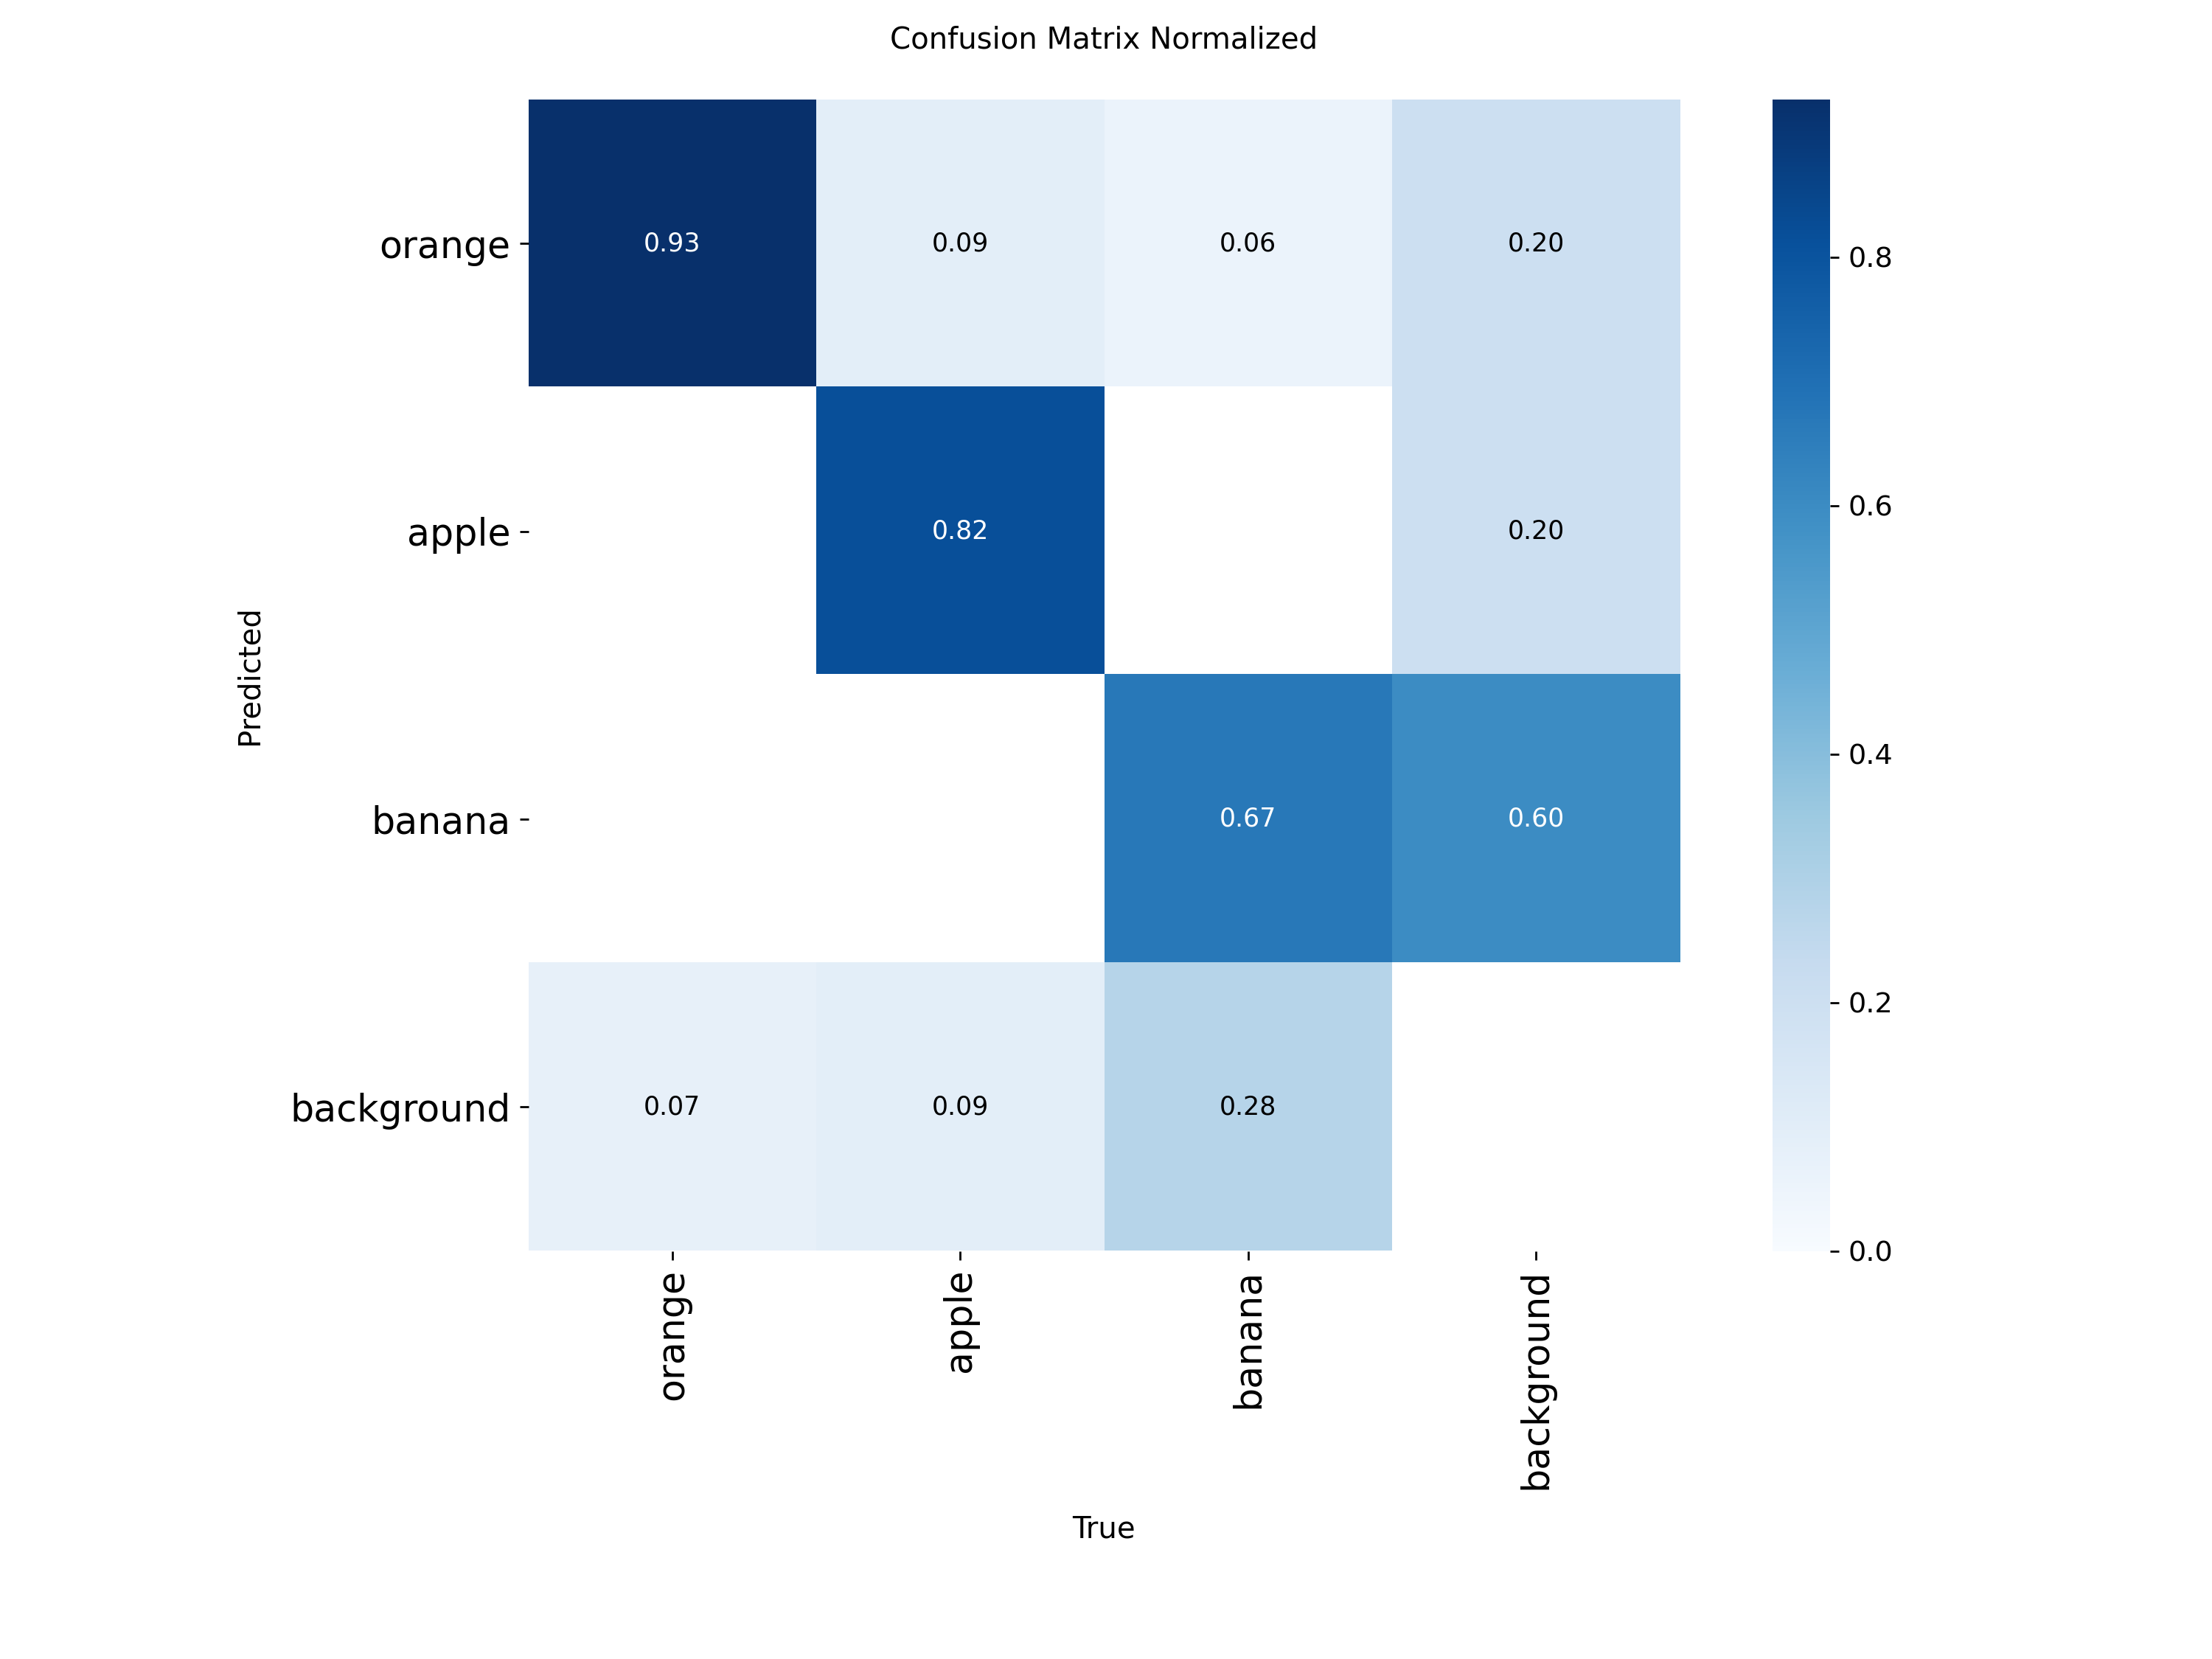

In [ ]:
%matplotlib inline
from PIL import Image

Image.open('/content/drive/MyDrive/custom_folder/train/confusion_matrix_normalized.png')

##Prediction

In [ ]:
model = YOLO("/content/drive/MyDrive/custom_folder/my_experiment/weights/best.pt")  # load a custom model

# Predict with the model with any image from internet?
results = model('https://www.freshpoint.com/wp-content/uploads/2019/08/freshpoint-produce-101-apples-bananas.jpg', save=True, project="/content/drive/MyDrive/custom_folder")


Found https://www.freshpoint.com/wp-content/uploads/2019/08/freshpoint-produce-101-apples-bananas.jpg locally at freshpoint-produce-101-apples-bananas.jpg
image 1/1 /content/freshpoint-produce-101-apples-bananas.jpg: 576x640 2 apples, 3 bananas, 16.4ms
Speed: 2.3ms preprocess, 16.4ms inference, 1.7ms postprocess per image at shape (1, 3, 576, 640)
Results saved to /content/drive/MyDrive/custom_folder/predict-2


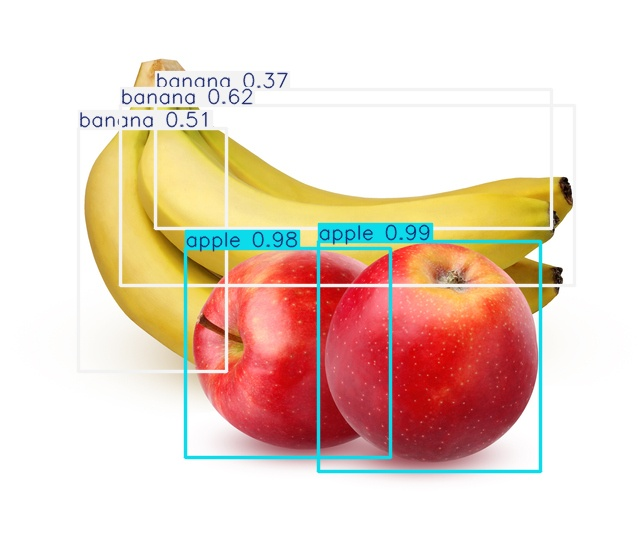

In [ ]:
# SHOW THE IMAGE STORED
%matplotlib inline
from PIL import Image

Image.open('/content/drive/MyDrive/custom_folder/predict-2/freshpoint-produce-101-apples-bananas.jpg')